In [292]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#DATA INFO

In [293]:
df = pd.read_csv('/content/drive/MyDrive/ML_learning/Practice/insurance.csv')

In [294]:
df.shape

(1338, 7)

In [295]:
df.sample(5)

,age,sex,bmi,children,smoker,region,charges
983,27,female,30.59,1,no,northeast,16796.41194
150,35,male,24.13,1,no,northwest,5125.21570
779,53,male,28.88,0,no,northwest,9869.81020
515,58,male,35.70,0,no,southwest,11362.75500
113,21,female,35.72,0,no,northwest,2404.73380


In [296]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [297]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [298]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [299]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [300]:
df.duplicated().sum()

np.int64(1)

In [301]:
df.drop_duplicates(inplace=True)

In [302]:
df.duplicated().sum()

np.int64(0)

In [303]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [304]:
df['children'].unique()

array([0, 1, 3, 2, 5, 4])

#EDA

##UNIVARIATE

###CATAGORICAL DATA PLOTS

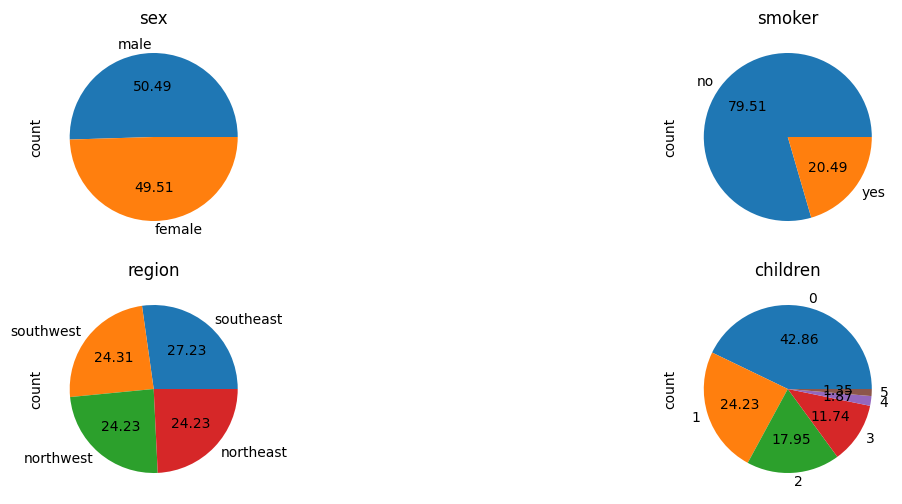

In [305]:
plt.figure(figsize=(15,6))



plt.subplot(221)
df['sex'].value_counts().plot(kind = 'pie',autopct='%.2f')
plt.title('sex')


plt.subplot(222)
df['smoker'].value_counts().plot(kind = 'pie',autopct='%.2f')
plt.title('smoker')

plt.subplot(223)
df['region'].value_counts().plot(kind = 'pie',autopct='%.2f')
plt.title('region')


plt.subplot(224)
df['children'].value_counts().plot(kind = 'pie',autopct='%.2f')
plt.title('children')




plt.show()

###NUMERICAL DATA PLOTS

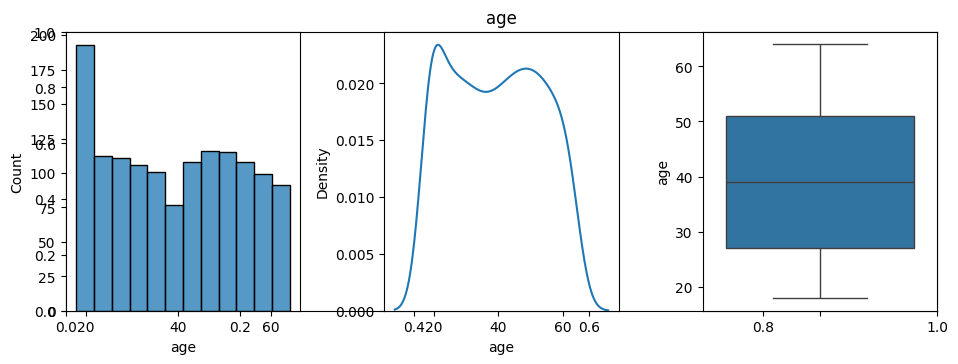

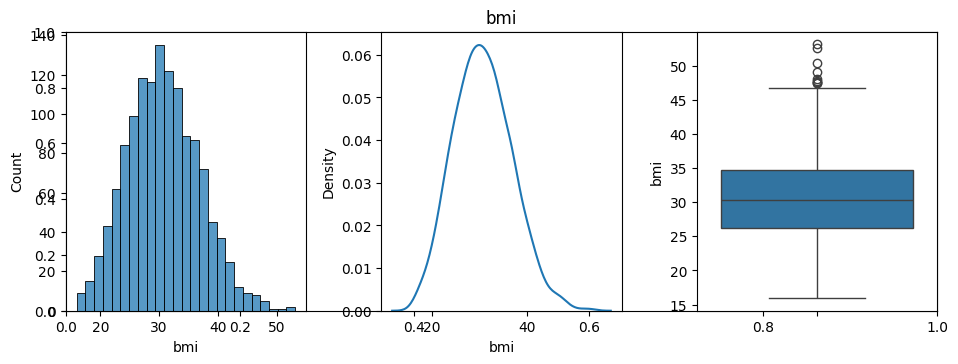

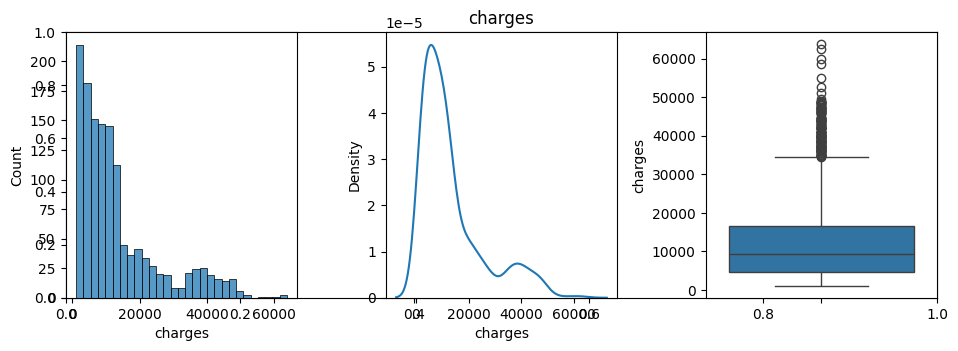

In [306]:

columns = ['age','bmi', 'charges']

for i in range(len(columns)):

  plt.figure(figsize=(10,4))

  plt.title(columns[i])

  plt.subplot(131)
  sns.histplot(df[columns[i]])

  plt.subplot(132)
  sns.distplot(df[columns[i]],hist=False)

  plt.subplot(133)
  sns.boxplot(df[columns[i]])

  plt.tight_layout()
  plt.show()

##BAIVARIATE

In [307]:
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<Axes: >

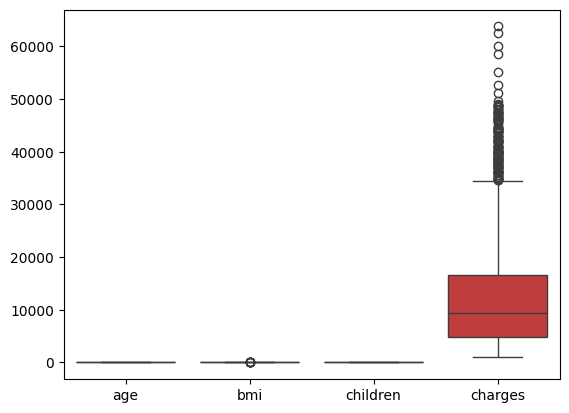

In [308]:
sns.boxplot(data=df[['age','bmi','children','charges']])

<Axes: xlabel='charges', ylabel='Count'>

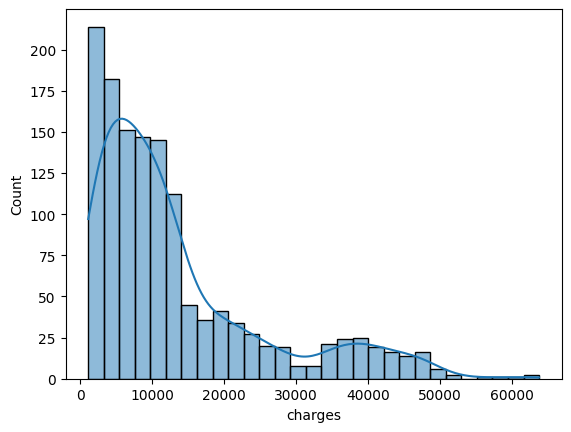

In [309]:
sns.histplot(df['charges'], kde=True)

<Axes: xlabel='smoker', ylabel='charges'>

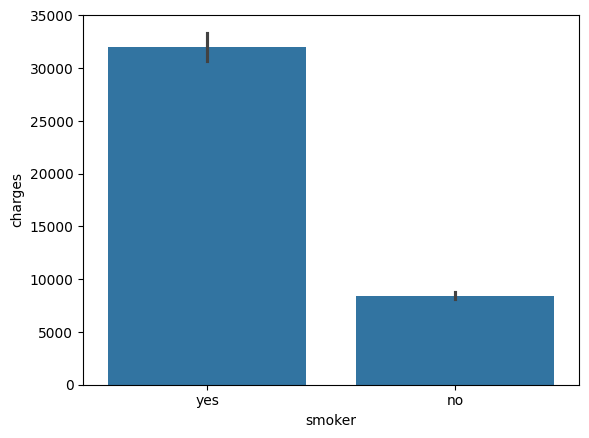

In [310]:
sns.barplot(x=df['smoker'], y=df['charges'])

<Axes: xlabel='region', ylabel='charges'>

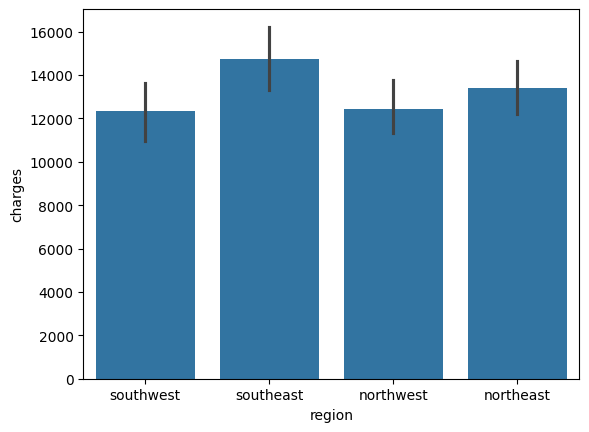

In [311]:
sns.barplot(x=df['region'], y = df['charges'])

<Axes: xlabel='region', ylabel='smoker'>

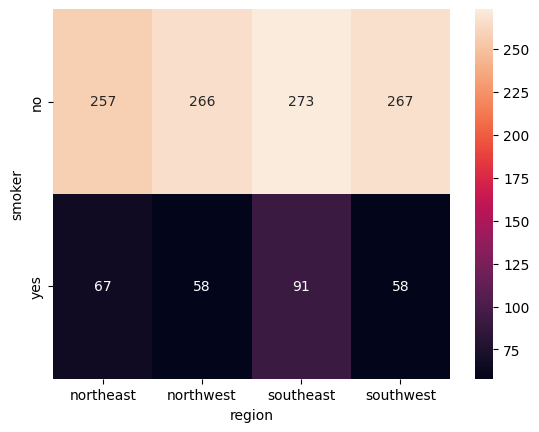

In [312]:
sns.heatmap(
    pd.crosstab(df['smoker'], df['region']),
    annot=True,
    fmt='d'
)

In [313]:
df.groupby('region')['charges'].mean()

,charges
region,
northeast,13406.384516
northwest,12450.840844
southeast,14735.411438
southwest,12346.937377


<Axes: xlabel='region', ylabel='bmi'>

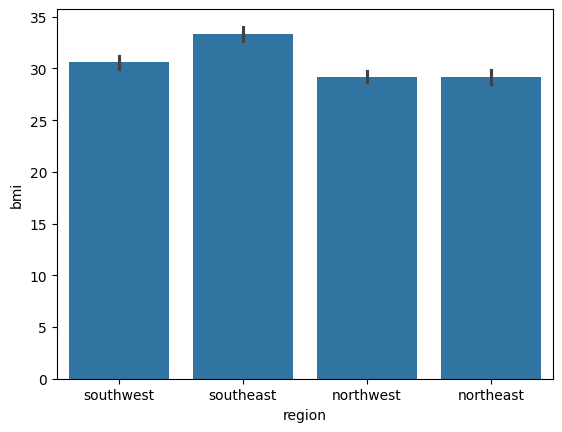

In [314]:
sns.barplot(x=df['region'], y = df['bmi'])

In [315]:
df.groupby('smoker')['age'].mean()

,age
smoker,
no,39.404516
yes,38.514599


<Axes: xlabel='smoker', ylabel='age'>

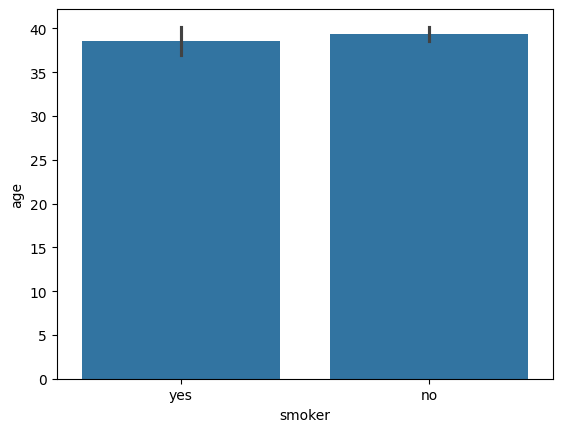

In [316]:
sns.barplot(x=df['smoker'], y = df['age'])
 #mean of the age
 #The average age of smokers and non-smokers is very similar in this dataset.

<Axes: xlabel='sex', ylabel='smoker'>

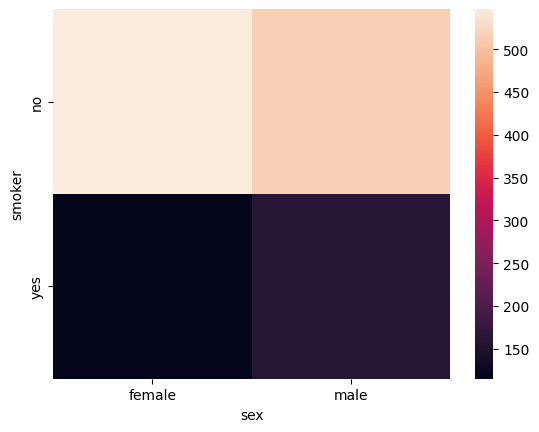

In [317]:
sns.heatmap(pd.crosstab(df['smoker'],df['sex']))

#approx same number of male and feamle smoke and do not smoke

<Axes: xlabel='smoker', ylabel='charges'>

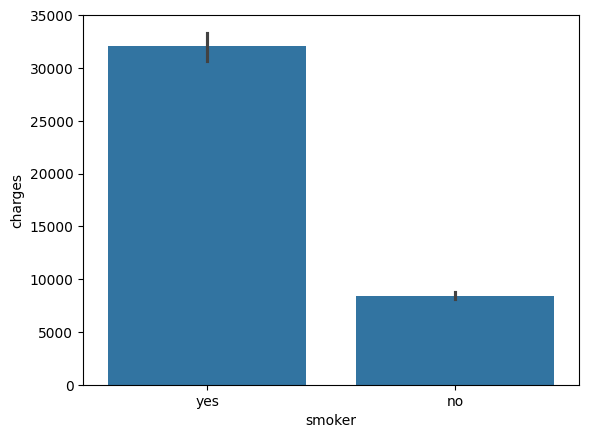

In [318]:
sns.barplot(x=df['smoker'],y=df['charges'])
#cmedical costs billed by health insurance is more for the smokers

<Axes: xlabel='age', ylabel='charges'>

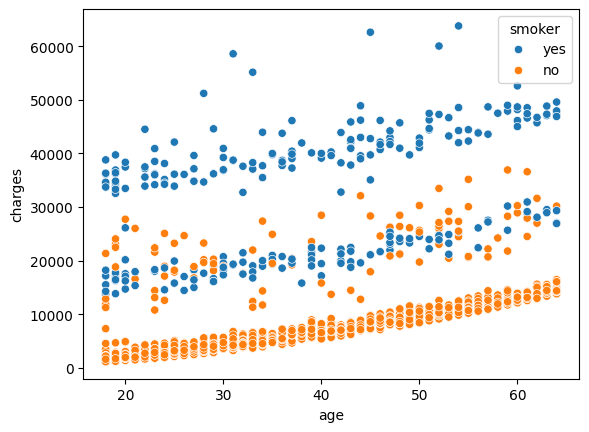

In [319]:
sns.scatterplot(x=df['age'], y=df['charges'], hue=df['smoker'])

In [320]:
df.sort_values('charges', ascending=False)[
    ['age','bmi','children','smoker','charges']
].head(20)

,age,bmi,children,smoker,charges
543,54,47.410,0,yes,63770.42801
1300,45,30.360,0,yes,62592.87309
1230,52,34.485,3,yes,60021.39897
577,31,38.095,1,yes,58571.07448
819,33,35.530,0,yes,55135.40209
1146,60,32.800,0,yes,52590.82939
34,28,36.400,1,yes,51194.55914
1241,64,36.960,2,yes,49577.66240
1062,59,41.140,1,yes,48970.24760
488,44,38.060,0,yes,48885.13561


In [321]:
avg = df['charges'].mean()

In [322]:
df[(df['age']>=18) & (df['age']<=25) & (df['charges']>avg)][['age','bmi','smoker','charges']].sort_values('charges', ascending=False)

,age,bmi,smoker,charges
1047,22,52.580,yes,44501.39820
292,25,45.540,yes,42112.23560
1124,23,42.750,yes,40904.19950
1156,19,44.880,yes,39722.74620
803,18,42.240,yes,38792.68560
...,...,...,...,...
1157,23,23.180,no,14426.07385
1282,18,21.660,yes,14283.45940
354,18,38.280,no,14133.03775
362,19,21.700,yes,13844.50600


In [323]:
df[(df['smoker']=='yes') &( df['charges']>avg)][['age','bmi','smoker','charges']].sort_values(['charges','age'])

,age,bmi,smoker,charges
1033,18,21.565,yes,13747.87235
362,19,21.700,yes,13844.50600
1282,18,21.660,yes,14283.45940
412,26,17.195,yes,14455.64405
989,24,20.520,yes,14571.89080
...,...,...,...,...
819,33,35.530,yes,55135.40209
577,31,38.095,yes,58571.07448
1230,52,34.485,yes,60021.39897
1300,45,30.360,yes,62592.87309


<Axes: xlabel='bmi', ylabel='charges'>

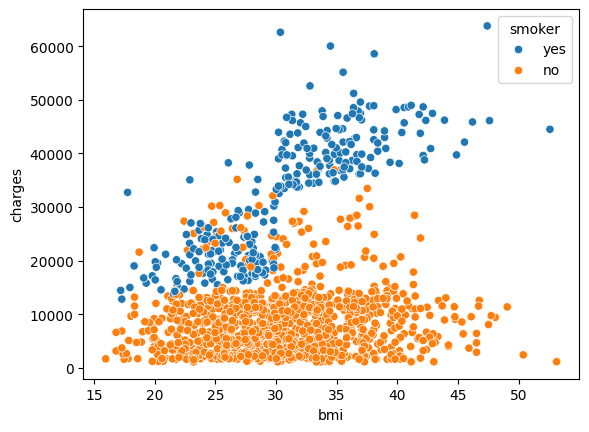

In [324]:
sns.scatterplot(
    x='bmi',
    y='charges',
    hue='smoker',
    data=df
)

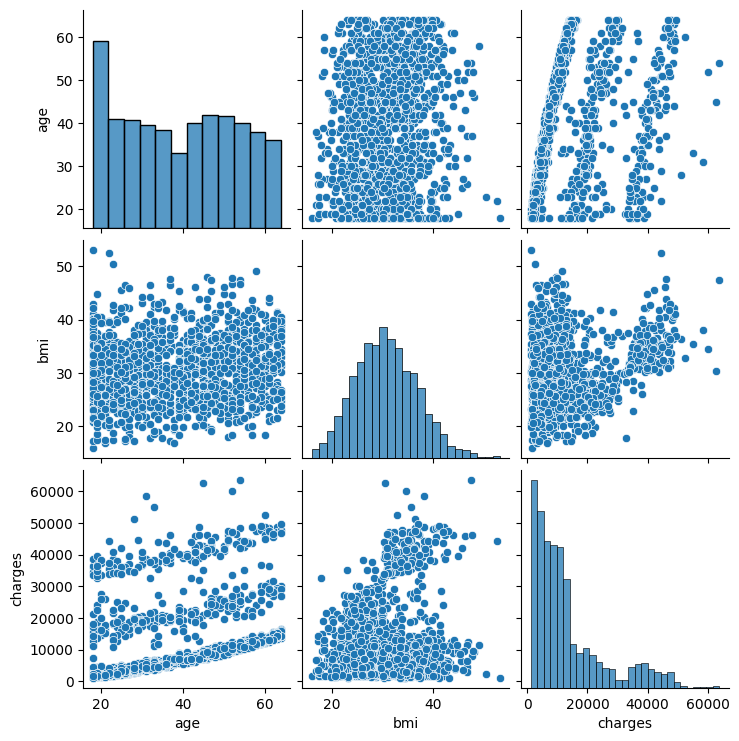

In [325]:

sns.pairplot(df[['age', 'bmi', 'charges']])
plt.show()

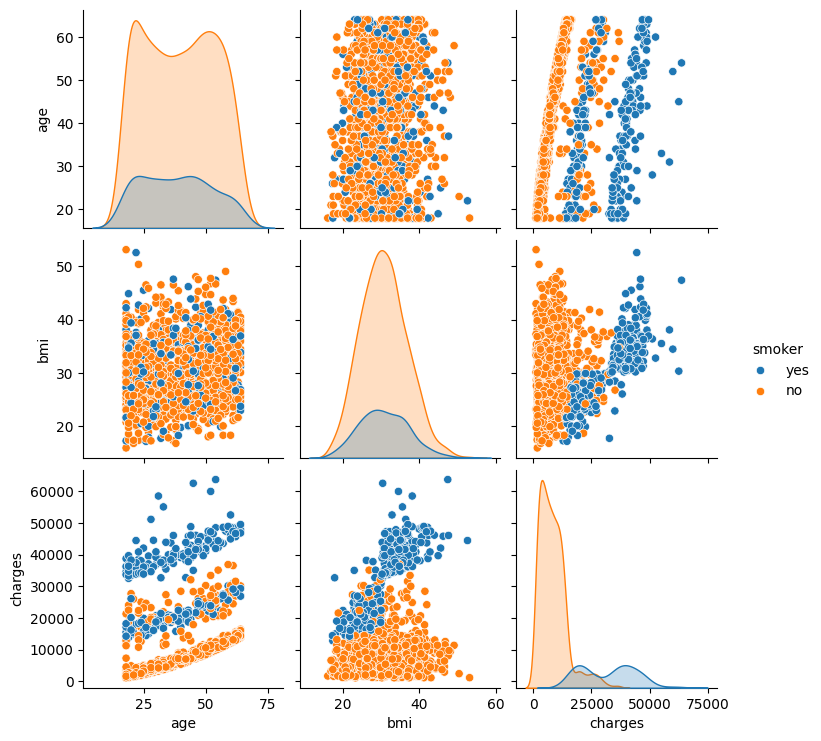

In [326]:
sns.pairplot(
    df[['age','bmi','charges','smoker']],
    hue='smoker'
)

<Axes: xlabel='age', ylabel='charges'>

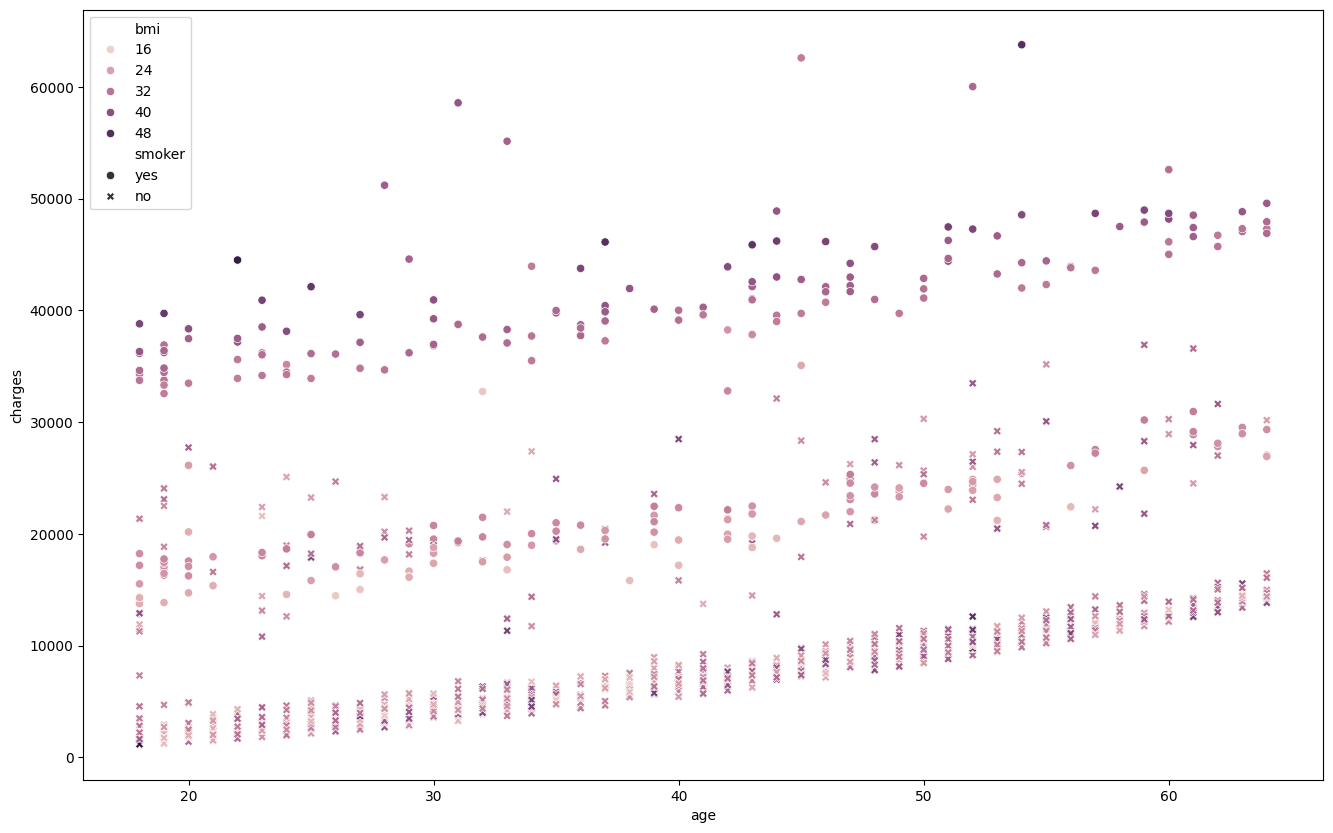

In [327]:
plt.figure(figsize=(16,10))
sns.scatterplot(x=df['age'], y =df['charges'],hue=df['bmi'], style = df['smoker'])

<Axes: xlabel='children', ylabel='charges'>

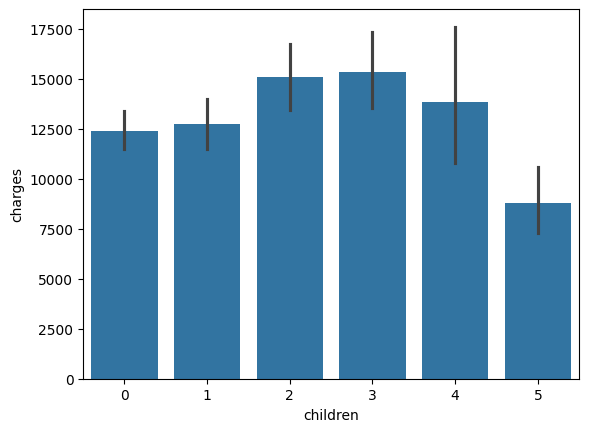

In [328]:
sns.barplot(x=df['children'], y=df['charges'])

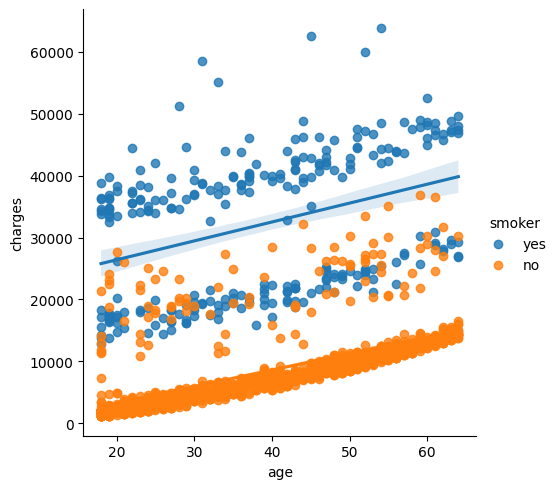

In [329]:
sns.lmplot(
    x='age',
    y='charges',
    hue='smoker',
    data=df
)

In [330]:
pd.crosstab(df['children'], df['smoker'])

smoker,no,yes
children,,
0,458,115
1,263,61
2,185,55
3,118,39
4,22,3
5,17,1


In [331]:
df[['children', 'charges']].corr()

,children,charges
children,1.000000,0.067389
charges,0.067389,1.000000


In [332]:
yes = df[df['smoker']=='yes']['charges'].mean()

no = df[df['smoker']=='no']['charges'].mean()

print(yes,no)

print(no-yes)

32050.23183153284 8440.660306508937
-23609.571525023905


In [333]:
!pip install ydata-Profiling

In [334]:
from ydata_profiling import ProfileReport
prof = ProfileReport(df)
prof.to_file(output_file = 'output.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 48.89it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

#FEATURE SELECTION

##HANDLING MISSING VALUES

In [335]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


NO MISSING VALUE THEREFORE NO NEED TO HANDLE THEM

In [336]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


##COLUMN DELETION(deleting unncessary columns)

In [337]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


##ENCODING AND SCALING

In [338]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

###TRAIN_TEST_SPLIT

In [339]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns=['charges']), df['charges'], test_size=0.2)

In [340]:
x_test

,age,sex,bmi,children,smoker,region
998,33,female,36.29,3,no,northeast
634,51,male,39.70,1,no,southwest
413,25,male,23.90,5,no,southwest
573,62,female,36.86,1,no,northeast
1170,18,male,27.36,1,yes,northeast
...,...,...,...,...,...,...
1146,60,male,32.80,0,yes,southwest
1014,38,female,27.60,0,no,southwest
847,23,male,50.38,1,no,southeast
350,57,female,23.18,0,no,northwest


In [350]:
transformer = ColumnTransformer(transformers=[
    ('tnf1',OneHotEncoder(drop='first',sparse_output=False),['sex','smoker','region']),
    ('tnf2',StandardScaler(),['age','bmi','children'])
], remainder='passthrough')

In [351]:
transformer.fit_transform(x_train)


array([[ 1.        ,  0.        ,  0.        , ...,  1.12456299,
         0.32779058, -0.0640821 ],
       [ 1.        ,  0.        ,  1.        , ..., -1.00227166,
         0.81058594, -0.89949384],
       [ 1.        ,  1.        ,  0.        , ...,  1.6917189 ,
         0.72317629, -0.89949384],
       ...,
       [ 0.        ,  0.        ,  1.        , ...,  0.34472362,
         1.0278847 , -0.0640821 ],
       [ 0.        ,  0.        ,  0.        , ..., -1.00227166,
        -0.3379932 , -0.89949384],
       [ 1.        ,  0.        ,  0.        , ...,  1.12456299,
         0.74850058, -0.0640821 ]])

In [352]:
transformer.transform(x_test)

array([[ 0.        ,  0.        ,  0.        , ..., -0.43511575,
         0.91923532,  1.60674139],
       [ 1.        ,  0.        ,  0.        , ...,  0.84098504,
         1.47636973, -0.0640821 ],
       [ 1.        ,  0.        ,  0.        , ..., -1.00227166,
        -1.10507415,  3.27756489],
       ...,
       [ 1.        ,  0.        ,  0.        , ..., -1.14406064,
         3.22129509, -0.0640821 ],
       [ 0.        ,  0.        ,  1.        , ...,  1.26635197,
        -1.22270957, -0.89949384],
       [ 1.        ,  0.        ,  0.        , ..., -1.49853308,
        -0.85019742, -0.89949384]])

In [353]:
x_train.shape

(1069, 6)

#PIPELINES

In [354]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [355]:
# Display Pipeline
from sklearn import set_config
set_config(display='diagram')

In [356]:
pipe = Pipeline([
    ('transformer',transformer),
    ('model',LinearRegression())
])

In [357]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tnf1',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['sex', 'smoker', 'region']),
                                                 ('tnf2', StandardScaler(),
                                                  ['age', 'bmi',
                                                   'children'])])),
                ('model', LinearRegression())])

In [ ]:
pipe.named_steps['transformer'].transformers_[0][1]

In [358]:
y_pred = pipe.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [359]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7801409931521275

In [362]:
# cross validation using cross_val_score
from sklearn.model_selection import cross_val_score
cross_val_score (pipe, x_train, y_train, cv=5, scoring='r2').mean()

np.float64(0.7369564954918072)

In [360]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 3943.4586950295748


In [361]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse}")

Root Mean Squared Error: 5600.618854451492
